<a href="https://colab.research.google.com/github/jaydenhurt1215-dotcom/CS4410-HW/blob/main/JHurt_hw_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

S1: Download NLTK resources

In [9]:
import nltk

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

S2: Download Hamlet text with requests

In [10]:
!pip install requests
import requests

target_url = 'https://www.gutenberg.org/files/2265/2265-0.txt'
response = requests.get(target_url)
data = response.text

In [11]:
print(data[:500])

*** START OF THE PROJECT GUTENBERG EBOOK 2265 ***


Executive Director's Notes:

In addition to the notes below, and so you will *NOT* think all
the spelling errors introduced by the printers of the time have
been corrected, here are the first few lines of Hamlet, as they
are presented herein:

  Barnardo. Who's there?
  Fran. Nay answer me: Stand & vnfold
your selfe

   Bar. Long liue the King

       *       *       *       *       *

As I understand it, the printers often ra


S3: Create TextBlob

In [12]:
from textblob import TextBlob

blob = TextBlob(data)

In [13]:
blob[:200]

TextBlob("*** START OF THE PROJECT GUTENBERG EBOOK 2265 ***


Executive Director's Notes:

In addition to the notes below, and so you will *NOT* think all
the spelling errors introduced by the printers of")

S4: Load english stop words

In [14]:
from nltk.corpus import stopwords

stop_words = stopwords.words('english')

In [15]:
stop_words[:20]

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been']

S5: Get word frequencies/ Remove stop words

In [18]:
import nltk
nltk.download('punkt_tab')
items = blob.word_counts.items()
items = [item for item in items if item[0] not in stop_words]

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


S6: Sort words by frequency

In [19]:
from operator import itemgetter
sorted_items = sorted(items, key=itemgetter(1), reverse=True)

In [20]:
sorted_items[:10]

[('ham', 337),
 ('lord', 211),
 ('haue', 175),
 ('king', 173),
 ('shall', 107),
 ('come', 106),
 ('thou', 105),
 ('let', 104),
 ('hamlet', 100),
 ('good', 98)]

S7: Get top 20 words

In [21]:
top20 = sorted_items[:20]
top20

[('ham', 337),
 ('lord', 211),
 ('haue', 175),
 ('king', 173),
 ('shall', 107),
 ('come', 106),
 ('thou', 105),
 ('let', 104),
 ('hamlet', 100),
 ('good', 98),
 ('hor', 95),
 ('thy', 90),
 ('enter', 85),
 ('oh', 81),
 ('like', 78),
 ('well', 70),
 ('may', 69),
 ('know', 69),
 ('selfe', 68),
 ('would', 68)]

S8: Put top 20 words into Pandas Dataframe

In [22]:
import pandas as pd

df = pd.DataFrame(top20, columns=['word', 'count'])
df

,word,count
0,ham,337
1,lord,211
2,haue,175
3,king,173
4,shall,107
5,come,106
6,thou,105
7,let,104
8,hamlet,100
9,good,98


S9: Create top20 bar chart

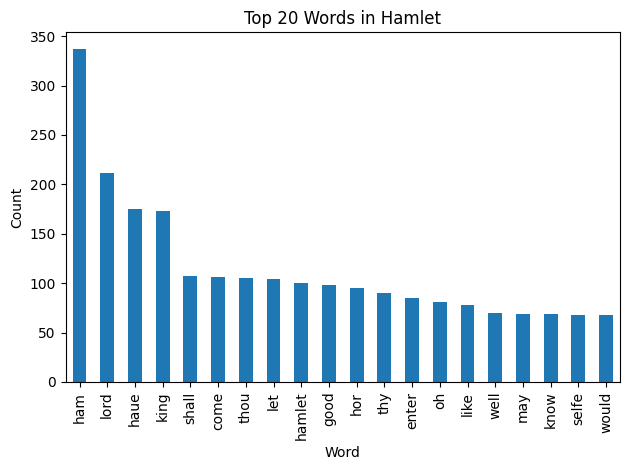

In [24]:
import matplotlib.pyplot as plt

axes = df.plot.bar(x='word', y='count', legend=False)

plt.title('Top 20 Words in Hamlet')
plt.xlabel('Word')
plt.ylabel('Count')

plt.gcf().tight_layout()
plt.show()

S10: Load Oval mask image

In [25]:
import imageio
image_file = "https://media.cheggcdn.com/media/216/21621ee5-e80f-47f3-9145-513f2229b390/phploeBuh.png"
mask_image = imageio.v3.imread(image_file)

In [26]:
mask_image.shape

(592, 1024, 3)

S11: Create Hamlet word cloud using oval mask

In [29]:
from wordcloud import WordCloud

wordcloud = WordCloud(
    colormap='prism',
    mask=mask_image,
    background_color='white'
)

wordcloud = wordcloud.generate(data)

S12: Display the Word Cloud

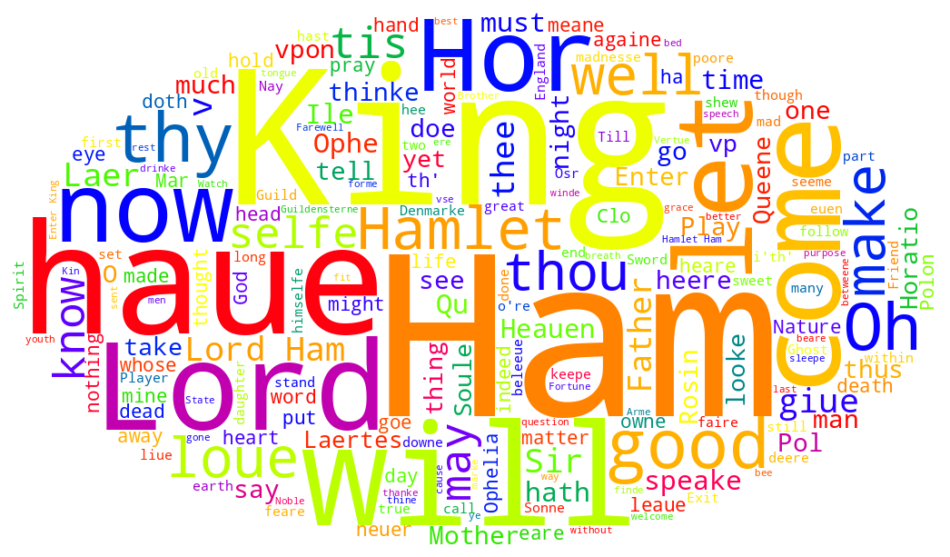

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()